# ASH_COATED_OSMIUM Dashboard

This notebook builds a focused dashboard for `ASH_COATED_OSMIUM` using the Round 1 price and trade CSVs in `data/ROUND_1`. It keeps the analysis centered on:

- level-1 bids and asks
- traded prices and quantities
- spread and book imbalance
- a practical market-making skew overview


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

plt.style.use('seaborn-v0_8-darkgrid')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

SYMBOL = 'ASH_COATED_OSMIUM'
DATA_DIR_CANDIDATES = [
    Path('data/ROUND_1'),
    Path('../data/ROUND_1'),
    Path('../../data/ROUND_1'),
]
DATA_DIR = next((path for path in DATA_DIR_CANDIDATES if path.exists()), None)
assert DATA_DIR is not None, f'Could not find data directory. Tried: {DATA_DIR_CANDIDATES}'

price_files = sorted(DATA_DIR.glob('prices_round_1_day_*.csv'))
trade_files = sorted(DATA_DIR.glob('trades_round_1_day_*.csv'))

assert price_files, f'No price files found in {DATA_DIR}'
assert trade_files, f'No trade files found in {DATA_DIR}'


In [2]:
def load_price_data() -> pd.DataFrame:
    frames = []
    for path in price_files:
        df = pd.read_csv(path, sep=';')
        df = df[df['product'] == SYMBOL].copy()
        for col in df.columns:
            if col != 'product':
                df[col] = pd.to_numeric(df[col], errors='coerce')
        df['source_file'] = path.name
        frames.append(df)

    prices = pd.concat(frames, ignore_index=True).sort_values(['day', 'timestamp']).reset_index(drop=True)
    prices['global_ts'] = (prices['day'] - prices['day'].min()) * 1_000_000 + prices['timestamp']
    prices['spread_1'] = prices['ask_price_1'] - prices['bid_price_1']
    prices['mid_from_quotes'] = (prices['bid_price_1'] + prices['ask_price_1']) / 2
    prices['microprice_l1'] = (
        prices['ask_price_1'] * prices['bid_volume_1']
        + prices['bid_price_1'] * prices['ask_volume_1']
    ) / (prices['bid_volume_1'] + prices['ask_volume_1'])
    prices['book_imbalance'] = (
        (prices['bid_volume_1'] - prices['ask_volume_1'])
        / (prices['bid_volume_1'] + prices['ask_volume_1'])
    )
    return prices


def load_trade_data() -> pd.DataFrame:
    frames = []
    for path in trade_files:
        df = pd.read_csv(path, sep=';')
        df = df[df['symbol'] == SYMBOL].copy()
        df['day'] = int(path.stem.split('_')[-1])
        for col in ['timestamp', 'price', 'quantity', 'day']:
            df[col] = pd.to_numeric(df[col], errors='coerce')
        df['source_file'] = path.name
        frames.append(df)

    trades = pd.concat(frames, ignore_index=True).sort_values(['day', 'timestamp']).reset_index(drop=True)
    trades['global_ts'] = (trades['day'] - trades['day'].min()) * 1_000_000 + trades['timestamp']
    trades['notional'] = trades['price'] * trades['quantity']
    return trades


prices = load_price_data()
trades = load_trade_data()

trade_context = pd.merge_asof(
    trades.sort_values('global_ts'),
    prices[[
        'global_ts', 'day', 'timestamp', 'bid_price_1', 'bid_volume_1', 'ask_price_1',
        'ask_volume_1', 'mid_price', 'mid_from_quotes', 'microprice_l1', 'spread_1', 'book_imbalance'
    ]].sort_values('global_ts'),
    on='global_ts',
    direction='backward',
    suffixes=('_trade', '_quote')
)
trade_context['trade_vs_mid'] = trade_context['price'] - trade_context['mid_price']
trade_context['trade_vs_microprice'] = trade_context['price'] - trade_context['microprice_l1']

display(prices.head())
display(trades.head())


,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss,source_file,global_ts,spread_1,mid_from_quotes,microprice_l1,book_imbalance
0,-2,0,ASH_COATED_OSMIUM,NaN,NaN,NaN,NaN,NaN,NaN,"10,010.00",25.00,NaN,NaN,NaN,NaN,"10,010.00",0.00,prices_round_1_day_-2.csv,0,NaN,NaN,NaN,NaN
1,-2,100,ASH_COATED_OSMIUM,"9,992.00",15.00,NaN,NaN,NaN,NaN,"10,008.00",15.00,"10,011.00",20.00,NaN,NaN,"10,000.00",0.00,prices_round_1_day_-2.csv,100,16.00,"10,000.00","10,000.00",0.00
2,-2,200,ASH_COATED_OSMIUM,"9,992.00",15.00,"9,989.00",30.00,NaN,NaN,"10,008.00",15.00,"10,010.00",30.00,NaN,NaN,"10,000.00",0.00,prices_round_1_day_-2.csv,200,16.00,"10,000.00","10,000.00",0.00
3,-2,300,ASH_COATED_OSMIUM,"9,992.00",13.00,"9,989.00",26.00,NaN,NaN,"10,008.00",13.00,"10,010.00",26.00,NaN,NaN,"10,000.00",0.00,prices_round_1_day_-2.csv,300,16.00,"10,000.00","10,000.00",0.00
4,-2,400,ASH_COATED_OSMIUM,"9,992.00",15.00,NaN,NaN,NaN,NaN,"10,008.00",15.00,"10,010.00",20.00,NaN,NaN,"10,000.00",0.00,prices_round_1_day_-2.csv,400,16.00,"10,000.00","10,000.00",0.00


,timestamp,buyer,seller,symbol,currency,price,quantity,day,source_file,global_ts,notional
0,700,NaN,NaN,ASH_COATED_OSMIUM,XIRECS,"9,990.00",6,-2,trades_round_1_day_-2.csv,700,"59,940.00"
1,900,NaN,NaN,ASH_COATED_OSMIUM,XIRECS,"9,998.00",2,-2,trades_round_1_day_-2.csv,900,"19,996.00"
2,2500,NaN,NaN,ASH_COATED_OSMIUM,XIRECS,"10,011.00",8,-2,trades_round_1_day_-2.csv,2500,"80,088.00"
3,6100,NaN,NaN,ASH_COATED_OSMIUM,XIRECS,"10,013.00",8,-2,trades_round_1_day_-2.csv,6100,"80,104.00"
4,12900,NaN,NaN,ASH_COATED_OSMIUM,XIRECS,"10,001.00",9,-2,trades_round_1_day_-2.csv,12900,"90,009.00"


In [3]:
overview = pd.DataFrame({
    'metric': [
        'Quote rows',
        'Trade rows',
        'Best bid availability',
        'Best ask availability',
        'Median quoted spread',
        'Mean quoted spread',
        'Median trade price',
        'VWAP',
        'Mean trade quantity',
        'Mean book imbalance',
        'Trade vs mid (mean)',
        'Trade vs microprice (mean)'
    ],
    'value': [
        len(prices),
        len(trades),
        prices['bid_price_1'].notna().mean(),
        prices['ask_price_1'].notna().mean(),
        prices['spread_1'].median(),
        prices['spread_1'].mean(),
        trades['price'].median(),
        trades['notional'].sum() / trades['quantity'].sum(),
        trades['quantity'].mean(),
        prices['book_imbalance'].mean(),
        trade_context['trade_vs_mid'].mean(),
        trade_context['trade_vs_microprice'].mean(),
    ]
})

day_summary = prices.groupby('day').agg(
    quote_rows=('timestamp', 'count'),
    bid_available=('bid_price_1', lambda s: s.notna().mean()),
    ask_available=('ask_price_1', lambda s: s.notna().mean()),
    spread_mean=('spread_1', 'mean'),
    spread_median=('spread_1', 'median'),
    mid_mean=('mid_price', 'mean'),
    imbalance_mean=('book_imbalance', 'mean')
).join(
    trade_context.groupby('day_trade').agg(
        trade_rows=('price', 'count'),
        trade_price_mean=('price', 'mean'),
        trade_price_median=('price', 'median'),
        trade_qty_mean=('quantity', 'mean'),
        trade_vs_mid_mean=('trade_vs_mid', 'mean')
    )
)

display(overview)
display(day_summary)


,metric,value
0,Quote rows,"30,000.00"
1,Trade rows,"1,265.00"
2,Best bid availability,0.96
3,Best ask availability,0.96
4,Median quoted spread,16.00
5,Mean quoted spread,16.18
6,Median trade price,"10,000.00"
7,VWAP,"10,000.24"
8,Mean trade quantity,5.21
9,Mean book imbalance,-0.00


,quote_rows,bid_available,ask_available,spread_mean,spread_median,mid_mean,imbalance_mean,trade_rows,trade_price_mean,trade_price_median,trade_qty_mean,trade_vs_mid_mean
day,,,,,,,,,,,,
-2,10000,0.96,0.96,16.15,16.00,"9,980.17",-0.00,429,"9,998.20","9,999.00",5.15,-0.04
-1,10000,0.96,0.96,16.19,16.00,"9,983.83",0.00,425,"10,000.77","10,001.00",5.24,-0.02
0,10000,0.96,0.96,16.18,16.00,"9,987.61",-0.00,411,"10,001.73","10,002.00",5.25,0.50


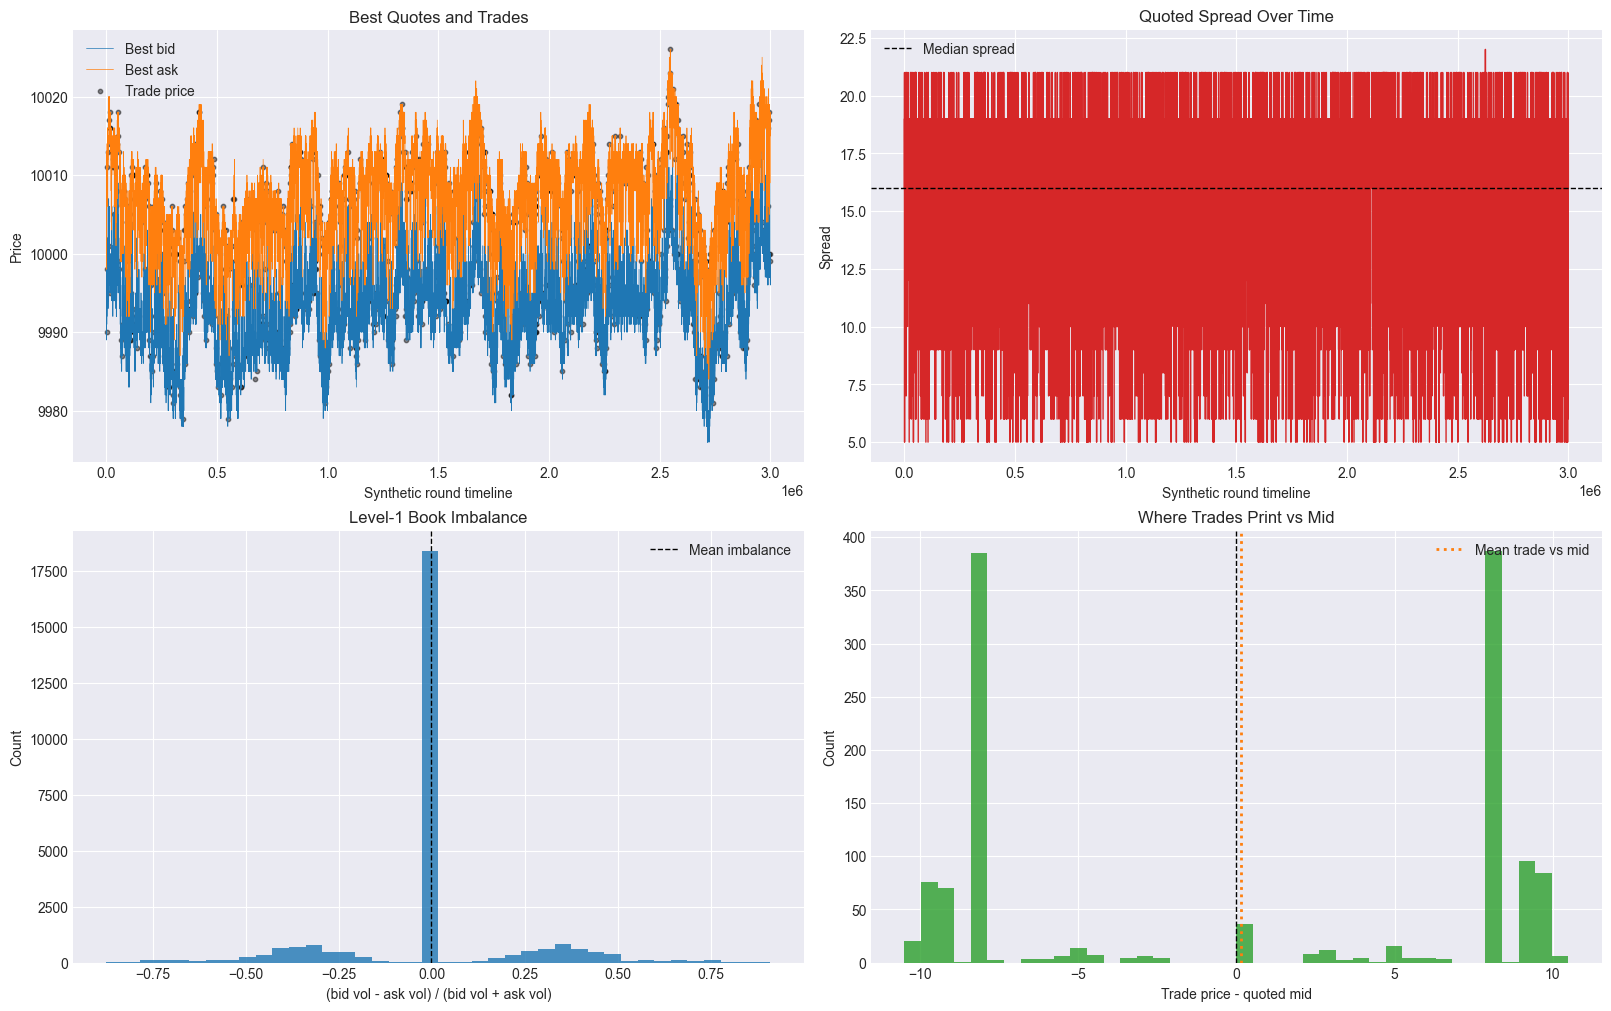

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10), constrained_layout=True)

axes[0, 0].plot(prices['global_ts'], prices['bid_price_1'], label='Best bid', linewidth=0.5)
axes[0, 0].plot(prices['global_ts'], prices['ask_price_1'], label='Best ask', linewidth=0.5)
axes[0, 0].scatter(trades['global_ts'], trades['price'], label='Trade price', s=10, alpha=0.45, color='black')
axes[0, 0].set_title('Best Quotes and Trades')
axes[0, 0].set_xlabel('Synthetic round timeline')
axes[0, 0].set_ylabel('Price')
axes[0, 0].legend()

axes[0, 1].plot(prices['global_ts'], prices['spread_1'], color='tab:red', linewidth=1.0)
axes[0, 1].axhline(prices['spread_1'].median(), color='black', linestyle='--', linewidth=1, label='Median spread')
axes[0, 1].set_title('Quoted Spread Over Time')
axes[0, 1].set_xlabel('Synthetic round timeline')
axes[0, 1].set_ylabel('Spread')
axes[0, 1].legend()

axes[1, 0].hist(prices['book_imbalance'].dropna(), bins=40, color='tab:blue', alpha=0.8)
axes[1, 0].axvline(prices['book_imbalance'].mean(), color='black', linestyle='--', linewidth=1, label='Mean imbalance')
axes[1, 0].set_title('Level-1 Book Imbalance')
axes[1, 0].set_xlabel('(bid vol - ask vol) / (bid vol + ask vol)')
axes[1, 0].set_ylabel('Count')
axes[1, 0].legend()

axes[1, 1].hist(trade_context['trade_vs_mid'].dropna(), bins=40, color='tab:green', alpha=0.8)
axes[1, 1].axvline(0, color='black', linestyle='--', linewidth=1)
axes[1, 1].axvline(trade_context['trade_vs_mid'].mean(), color='tab:orange', linestyle=':', linewidth=2, label='Mean trade vs mid')
axes[1, 1].set_title('Where Trades Print vs Mid')
axes[1, 1].set_xlabel('Trade price - quoted mid')
axes[1, 1].set_ylabel('Count')
axes[1, 1].legend()

plt.show()


In [5]:
latest_quotes = prices[['day', 'timestamp', 'bid_price_1', 'bid_volume_1', 'ask_price_1', 'ask_volume_1', 'mid_price', 'spread_1']].tail(12)
largest_trades = trades[['day', 'timestamp', 'price', 'quantity', 'notional']].sort_values(['quantity', 'notional'], ascending=[False, False]).head(12)

display(latest_quotes)
display(largest_trades)


,day,timestamp,bid_price_1,bid_volume_1,ask_price_1,ask_volume_1,mid_price,spread_1
29988,0,998800,"10,000.00",15.00,"10,016.00",15.00,"10,008.00",16.00
29989,0,998900,"10,000.00",11.00,NaN,NaN,"10,000.00",NaN
29990,0,999000,"9,999.00",15.00,"10,015.00",15.00,"10,007.00",16.00
29991,0,999100,"9,999.00",13.00,"10,015.00",13.00,"10,007.00",16.00
29992,0,999200,"9,997.00",24.00,"10,015.00",13.00,"10,006.00",18.00
29993,0,999300,"9,996.00",26.00,"10,015.00",12.00,"10,005.50",19.00
29994,0,999400,"9,999.00",10.00,"10,015.00",10.00,"10,007.00",16.00
29995,0,999500,"10,000.00",13.00,"10,018.00",28.00,"10,009.00",18.00
29996,0,999600,"10,000.00",14.00,"10,016.00",14.00,"10,008.00",16.00
29997,0,999700,"10,000.00",11.00,"10,016.00",11.00,"10,008.00",16.00


,day,timestamp,price,quantity,notional
575,-1,337000,"10,019.00",10,"100,190.00"
1251,0,944500,"10,015.00",10,"100,150.00"
23,-2,48000,"10,014.00",10,"100,140.00"
566,-1,320700,"10,013.00",10,"100,130.00"
596,-1,379500,"10,013.00",10,"100,130.00"
860,0,12500,"10,013.00",10,"100,130.00"
924,0,191200,"10,013.00",10,"100,130.00"
1102,0,591500,"10,013.00",10,"100,130.00"
18,-2,36700,"10,012.00",10,"100,120.00"
649,-1,524200,"10,012.00",10,"100,120.00"


In [6]:
median_spread = prices['spread_1'].median()
mean_imbalance = prices['book_imbalance'].mean()
trade_bias_mid = trade_context['trade_vs_mid'].mean()
trade_bias_micro = trade_context['trade_vs_microprice'].mean()
day0_bias_mid = trade_context.loc[trade_context['day_trade'] == 0, 'trade_vs_mid'].mean()

skew_lines = [
    '## Market-Making Skew Overview',
    '',
    f'- The quoted market is consistently wide: the median level-1 spread is **{median_spread:.1f} ticks**.',
    f'- The book is close to balanced on average: mean imbalance is **{mean_imbalance:.3f}**, so there is no strong persistent one-sided pressure.',
    f'- Trades print only **{trade_bias_mid:.2f} ticks above mid on average** and **{trade_bias_micro:.2f} ticks above microprice on average**, which is a mild upward bias rather than a strong trend.',
    f'- Day `0` is the strongest bullish session, with trades printing about **{day0_bias_mid:.2f} ticks above mid** on average.',
    '',
    '### Practical takeaway',
    '',
    '- Start from a mostly neutral fair value rather than hard-skewing inventory one way all day.',
    '- Because the spread is wide, your edge mostly comes from disciplined quote placement and inventory control, not from chasing every trade print.',
    '- A small positive skew is reasonable when recent trades keep lifting above mid or when microprice is above mid: think in terms of shifting fair value up by roughly **0.5 to 1 tick**, not several ticks.',
    '- If inventory gets long, mean reversion in the trade distribution argues for fading that bias back toward neutral instead of continuing to lean upward aggressively.',
    '- If you want a simple live rule, use `microprice - mid_price` plus recent `trade_vs_mid` as the fast skew signal, while keeping your default inventory skew close to flat.'
]

display(Markdown('\n'.join(skew_lines)))


## Market-Making Skew Overview

- The quoted market is consistently wide: the median level-1 spread is **16.0 ticks**.
- The book is close to balanced on average: mean imbalance is **-0.002**, so there is no strong persistent one-sided pressure.
- Trades print only **0.14 ticks above mid on average** and **0.16 ticks above microprice on average**, which is a mild upward bias rather than a strong trend.
- Day `0` is the strongest bullish session, with trades printing about **0.50 ticks above mid** on average.

### Practical takeaway

- Start from a mostly neutral fair value rather than hard-skewing inventory one way all day.
- Because the spread is wide, your edge mostly comes from disciplined quote placement and inventory control, not from chasing every trade print.
- A small positive skew is reasonable when recent trades keep lifting above mid or when microprice is above mid: think in terms of shifting fair value up by roughly **0.5 to 1 tick**, not several ticks.
- If inventory gets long, mean reversion in the trade distribution argues for fading that bias back toward neutral instead of continuing to lean upward aggressively.
- If you want a simple live rule, use `microprice - mid_price` plus recent `trade_vs_mid` as the fast skew signal, while keeping your default inventory skew close to flat.